In [10]:
import sys, os, pickle
from datetime import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed

SRC_PATH = '/content/drive/MyDrive/ellis-attribution/src'
sys.path.insert(0, SRC_PATH)

from src.attribution import (
    compute_pn,
    run_thermo_ml,
    run_dyn_adj_local,
    run_dml_dyn_adj_local
)
from src.analogues import (
    run_analogues,
    run_analogues_local,
    run_analogues_local_lasso,
    run_analogues_causal_knn
)
from src.data_utils import extract_local_slp

from matplotlib import pyplot as plt
from src.sparse_unconditional_analogues import KNNAnalogueAttributor

from src.visualization import *

In [2]:
# ================================================================
#  CONFIG  —  edit here
# ================================================================
path_extracted = '/home/homer/Documents/Research/Data/attribution_evaluation_data/extracted/'
DATA_PATH    = path_extracted + 'extracted_tasmax_nmem10_start2004_p99.9.pkl'

RESULTS_DIR = 'results'

# PN estimators to run for every method
# Options: 'empirical', 'gaussian', 'gev'  (can select multiple)
STAT_METHODS = ['gaussian']

# Time window around each event
WINDOW_BEFORE = 72   # months
WINDOW_AFTER  = 12   # months

N_JOBS = 2#os.cpu_count()
# ================================================================

In [3]:
with open(DATA_PATH, 'rb') as fh:
    data = pickle.load(fh)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [36]:
# =============================================================================
# 1. PREPROCESSING  (unchanged)
# =============================================================================

def preprocess_attribution_data(slp_f, slp_c, slp_lat, slp_lon, ev_lat, ev_lon,
                                  half_width_deg=30.0, n_pcs=10, factual=True):
    lat_idx = np.where((slp_lat >= ev_lat - half_width_deg) &
                       (slp_lat <= ev_lat + half_width_deg))[0]
    lon_idx = np.where((slp_lon >= ev_lon - half_width_deg) &
                       (slp_lon <= ev_lon + half_width_deg))[0]

    slp_local_f = slp_f[:, lat_idx, :][:, :, lon_idx]
    slp_local_c = slp_c[:, lat_idx, :][:, :, lon_idx]

    X_f = slp_local_f.reshape(slp_local_f.shape[0], -1)
    X_c = slp_local_c.reshape(slp_local_c.shape[0], -1)

    X_all = X_f if factual else X_c

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)

    pca = PCA(n_components=n_pcs)
    pca.fit(X_scaled)
    X_pcs = pca.transform(X_scaled)

    return X_pcs, pca, X_scaled


# =============================================================================
# 2. MAIN LOOP — one row per (event, scenario)
# =============================================================================

def run_all_events(data, dataset_idx=0, half_width_deg=20.0, n_pcs=30,
                   lasso_method='lasso', n_analogues=None):
    """
    Returns a single DataFrame with one row per (event_id, scenario).

    Columns mirror the process_event() convention:
        member, event_id, scenario, lat, lon,
        pn_knn, rr_knn, cr_knn, n_analogues_knn
    """
    for dataset_idx in range(len(data)):
        d        = data[dataset_idx]
        n_events = len(d['c_tas_vals'])
        rows     = []

        for event in tqdm(range(10)):

            tas_f      = d['f_tas'][:, event]
            tas_c      = d['c_tas'][:, event]
            slp_f      = d['f_slp']
            slp_c      = d['c_slp']
            slp_lat    = d['slp_lat']
            slp_lon    = d['slp_lon']
            ev_lat, ev_lon = d['location'][event]
            obs_val    = d['c_tas_vals'][event]
            idx_event  = d['idx_f'][event]

            past_idx    = np.arange(12 * 50)
            present_idx = np.arange(idx_event - 12 * 5, idx_event)
            t_obs_int   = int(idx_event)


            for factual in [True, False]:
                row = {
                'event_id': event,
                'lat':      ev_lat,
                'lon':      ev_lon,
                'obs_val':  obs_val,
                }
                scenario = 'factual' if factual else 'counterfactual'
                suffix   = 'f' if factual else 'c'

                X_pcs, _, _ = preprocess_attribution_data(
                    slp_f, slp_c, slp_lat, slp_lon, ev_lat, ev_lon,
                    half_width_deg=half_width_deg, n_pcs=n_pcs,
                    factual=factual,
                )
                tas_all = tas_f if factual else tas_c

                attributor = KNNAnalogueAttributor(
                    n_analogues=n_analogues, metric='euclidean'
                )
                attributor.fit_features(X_pcs, tas_all, past_idx,
                                        method=lasso_method)

                res = attributor.compute_attribution(
                    t_obs=t_obs_int,
                    past_idx=past_idx,
                    present_idx=present_idx,
                    tas_data=tas_all,
                    obs_val=obs_val,
                )

                row[f'pn'] = res['pn']
                row['scenario'] = scenario
                rows.append(row)

    print("Done.")
    return pd.DataFrame(rows)


# =============================================================================
# 3. ENTRY POINT
# =============================================================================

print("Running attribution for all events...")
df = run_all_events(
    data,
    dataset_idx=0,
    half_width_deg=12.5,
    n_pcs=20,
    lasso_method='lasso',
    n_analogues=None,
)


Running attribution for all events...


100%|██████████| 10/10 [00:09<00:00,  1.08it/s]

Done.


In [32]:
algo_groups = {
    'Analogues': [
        ('Analogues', 'pn',   'red')
    ]
}

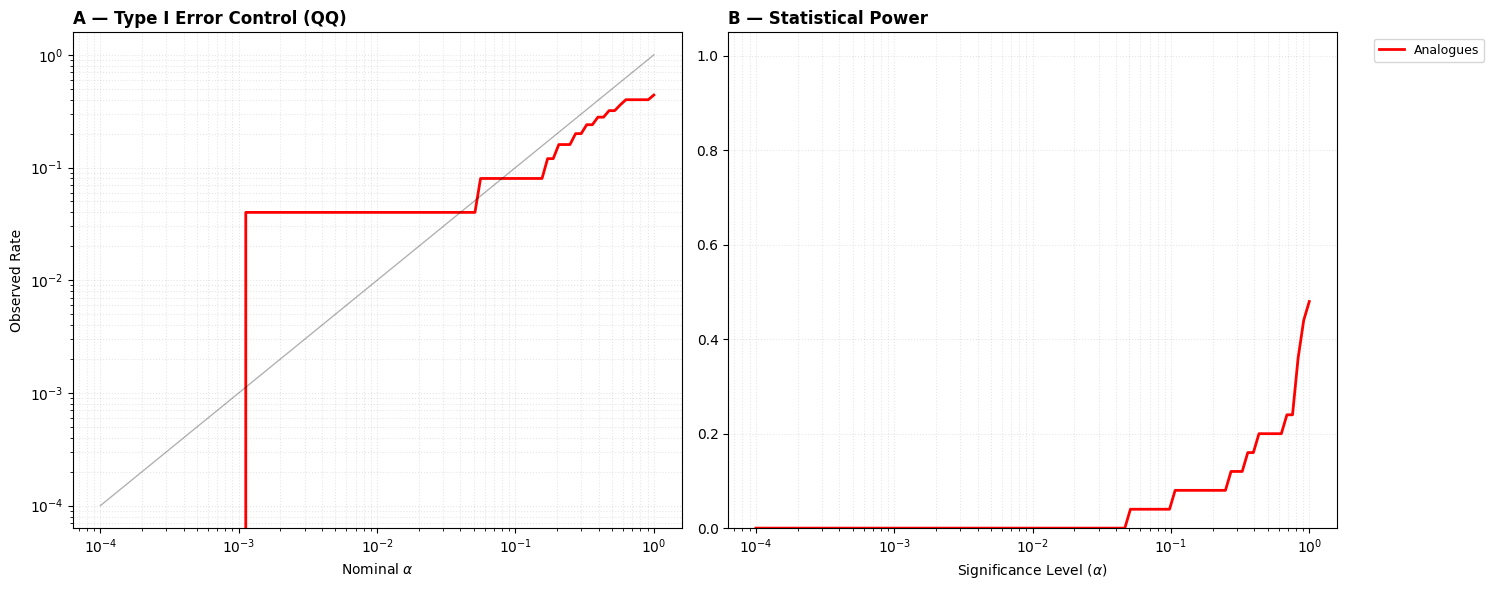

Saved -> figures/qq_analysis.png


In [33]:
plot_qq_analysis(
    df, algo_groups)